# Introduction to Artificial Intelligence in Energy Engineering – 2026
### Albieri M. Alana, Estudiante de Ing Informática URBE
### 2026
***
## Week 3 Workbook
***

##**1.	Define and describe the following:**

###**a.	Big Data**

Hay muchos conceptos referentes a este tema, sin embargo una buena forma de definir que es la big data es basicamente cuando las 3 Vs se juntan

1.   Volumen: Una cantidad absurda de datos generados.
2.   Velocidad: Esta cantidad de datos se genera en segundos o menos.
3.   Variedad: A las dos anteriores, sumamos la diversidad de formatos en los cuales obtenemos esta data.

Al tener estas 3 variantes juntas, podriamos decir que tenemos big data, definiendole asi como conjuntos de datos inmensos y de procesamiento complejo.



###**b.	Parameter vs. Statistic vs. Hyperparameter**

Son tres conceptos similares pero diferentes entre si, podemos definirles de la siguiente forma:

1.   Hyperparameter: Son ajustes internos que le realizamos a nuestros modelos, como ejemplo podriamos tomar la cantidad de clusteres en un modelos de clasificacion
2.   Parameter: Son los valores o pesos que le ingresaremos a nuestro modelo para entrenarle y que aprenda el requerimiento necesario
3.   Statistic: Hace referencia a los valores obtenidos despues de nuestro analisis, un porcentaje o similar



###**c.	Inferential vs. Predictive Machine Learning**



1.   Inferential Machine Learning: Este enfoque se centra en entender el porque de nuestros resultados, explica el como afecta una variable a otra, como afecta X a Y, correlaciones etc, modelos usados normalmente bajo este enfoque son regresiones lineales simples.

2.   Predictive Machine Learning: Este enfoque deja de lado el porque y se enfoca directamente en los resultados, su objetivo mas alla de el porque, ataca directamente los resultados, bajo este enfoque se suelen usar redes neuronales.

Basicamente, Aunque ambos buscan predecir algun valor, ambos toman caminos diferentes para llegar al resultado deseado.



###**d.	Bias-Variance Tradeoff**

Este es un concepto bastante interesante, basicamente habla del equilibrio que se debe tener en nuestros modelos, Buscar el equilibrio entre un bajo Bias o error y una baja varianza, busca el equilibrio entre los puntos mas bajos de estos nos llevara al mejor modelo posible

###**e.	Train-Test Split, Validation, and Cross-Validation**

Un punto fundamental antes de llevar nuestros modelos es hacerle pruebas para validar su correcto funcionamiento ademas claro, de tener cierta fiabilidad en sus resultados. Aqui entran dos formas de trabajo para realizarle pruebas a nuestro modelo, la primera **Train-Test Split** hace referencia a separar nuestro conjunto de datos en un 80/20 en la mayoria de casos, aunque es algo relativamente a juicio de el Data Scientist, sin embargo en muchos casos la fiabilidad es relativamente baja cuando nuestro conjunto de datos es bajo, alli entra el Cross-Validation, el cual consiste en dividir en 5 conjuntos nuestros datos, luego usar 4 partes para entrenarle y la restante de validacion, luego ir moviendo la validacion entre los otros 4 sub conjuntos, la idea es que se usen de validacion los otros 4 conjuntos, luego en cada metrica que sera diferente como resultado, promediar los 5 resultados y alli la metrica aproximada de confiabilidad en el modelo.

Es importante tomar en cuenta que en ambas formas de trabajo dividiriamos en 80/20 nuestros datos, luego el 20% no se toca para entrenamientos. El 80% es el usado para entrenar y sacar de alli un 10% para validacion del modelo, eso en Train-Test Split, en coss validation el 80% se divide en 5 sub conjuntos, 4 de entrenamiento y 1 de validacion.

###**f.	Regularized Regression**

Cuando hablamos de regresiones regularizadas hacemos referencia a que en ocasiones, tenemos muchas variables o features en nuestro dataset, la mayoria variables que solo causan ruido o estan estrechamente correlacionadas, lo cual lleva a que generemos un modelo con un alto overfitting, el cual tenga dificultades para generalizar y producir predicciones mas acertadas. Para cubrir esta necesidad surgen dos formas de atacarle:

1.   Modelo lineal regularizado de Lasso (L1): Añade una penalización igual al valor absoluto de la magnitud de los coeficientes. Puede resultar en coeficientes iguales a cero, lo que indica que la característica correspondiente no se utiliza en el modelo.

2.   Modelo lineal regularizado de Ridge (L2): Añade una penalización igual al cuadrado de la magnitud de los coeficientes. Esto tiende a reducir los coeficientes, pero no los hace exactamente cero, por lo que todas las características se mantienen en el modelo.

La fuerza de esta penalización en ambos modelos está controlada por un hiperparámetro (comúnmente llamado $\lambda$ o $\alpha$), el cual ajustamos mediante Cross-Validation para encontrar el equilibrio perfecto.






##**2.	Exploratory Data Analysis (EDA)**

### **a.	Load the dataset using pandas. Calculate the summary statistics (use pd.describe()). Create a figure with subplots relating several features to the target variable, and/or histograms to show the distributions. Comment on any interesting findings, values, patterns, etc.**

#### 1. Cargar el dataset y primeras exploraciones

Primero, se importan las librerías necesarias `pandas` para la manipulación de datos, `matplotlib.pyplot` y `seaborn` para visualizaciones (aunque aún no se han utilizado en esta etapa inicial, se importaron previamente).

Luego, se carga el dataset desde una URL de GitHub en un DataFrame de pandas llamado `df_fails` y se muestran los nombres de las columnas para tener una visión general de las características disponibles.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_fails = pd.read_csv('https://github.com/Albieri151/Ejercicios-Data-Science-Petroleo/raw/refs/heads/main/Week%203/esp.csv')
df_fails.columns

Index(['FAIL', 'Oil', 'Gas', 'Water', 'Drive_Current', 'Drive_Voltage',
       'Intake_Pressure', 'Motor_Shutdown_Temp', 'Motor_Winding_Temp',
       'Output_Frequency', 'Vibration_X', 'Startup_Count', 'Oil_Intake',
       'Water_Intake', 'Gas_Intake', 'Liquid_Intake',
       'Gas_Saturation_at_Intake', 'Gas_Separator_Efficiency',
       'Gas_through_Annulus_Intake', 'Gas_through_ESP_Intake',
       'Gas_through_Annulus', 'Gas_through_ESP', 'Pb_ESP',
       'Discharge_Pressure', 'ESP_Fluid', 'Gas_Saturation_at_Discharge',
       'Pump_Delta_Pressure', 'Pump_Average_Pressure',
       'Gas_Saturation_in_Pump', 'Pump_Power', 'Drive_Power', 'Power_Ratio',
       'Power_Difference', 'ESP_Temperature', 'Lower_Limit'],
      dtype='object')

#### 2. Estadísticas Descriptivas

Se generaron las estadísticas descriptivas del DataFrame `df_fails` usando `.describe().T`. Esto proporciona un resumen rápido de las tendencias centrales, dispersión y forma de la distribución de cada columna numérica, incluyendo el conteo, la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles.

In [27]:
df_fails.describe().T

,count,mean,std,min,25%,50%,75%,max
FAIL,18416.0,0.082917,0.275764,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000
Oil,18416.0,547.115948,365.729121,0.000000,2.797687e+02,4.452471e+02,750.404411,3217.720003
Gas,18416.0,695.987462,345.010474,0.000000,4.473148e+02,6.525302e+02,915.066465,3406.650214
Water,18416.0,789.477416,589.494135,0.000000,3.541407e+02,6.127823e+02,1066.437639,4406.485759
Drive_Current,18416.0,255.558201,59.849457,78.699997,2.271930e+02,2.559780e+02,292.461351,570.267352
Drive_Voltage,18416.0,418.540853,36.035441,199.903102,3.915532e+02,4.233560e+02,443.513287,484.887918
Intake_Pressure,18416.0,1048.540334,519.295452,300.599873,7.383919e+02,9.233329e+02,1199.452427,3707.563719
Motor_Shutdown_Temp,18416.0,338.585812,525.692612,0.000000,2.300000e+02,2.300000e+02,240.000000,4460.000000
Motor_Winding_Temp,18416.0,179.404368,9.232201,135.223159,1.730551e+02,1.788293e+02,184.730163,260.799988
Output_Frequency,18416.0,55.516712,5.019085,9.835111,5.200000e+01,5.700000e+01,60.000000,65.000000


#### 3. Información General del DataFrame

El método `.info()` se utilizó para obtener un resumen conciso del DataFrame, incluyendo el número de entradas, el número total de columnas, los tipos de datos de cada columna, la cantidad de valores no nulos en cada columna y el uso de memoria.

In [28]:
df_fails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18416 entries, 0 to 18415
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   FAIL                         18416 non-null  int64  
 1   Oil                          18416 non-null  float64
 2   Gas                          18416 non-null  float64
 3   Water                        18416 non-null  float64
 4   Drive_Current                18416 non-null  float64
 5   Drive_Voltage                18416 non-null  float64
 6   Intake_Pressure              18416 non-null  float64
 7   Motor_Shutdown_Temp          18416 non-null  float64
 8   Motor_Winding_Temp           18416 non-null  float64
 9   Output_Frequency             18416 non-null  float64
 10  Vibration_X                  18416 non-null  float64
 11  Startup_Count                18416 non-null  float64
 12  Oil_Intake                   18416 non-null  float64
 13  Water_Intake    

#### 4. Distribución de la Variable Objetivo 'FAIL'

Finalmente, se calculó la distribución de la variable objetivo 'FAIL' utilizando `value_counts(normalize=True)`. Esto muestra la proporción de las clases (0 y 1) en esta columna, indicando si el dataset está desbalanceado con respecto a la ocurrencia de fallas.

In [29]:
df_fails['FAIL'].value_counts(normalize=True)

,proportion
FAIL,
0,0.917083
1,0.082917


#### **5. Procedemos a crear los subplots para visualizar relaciones entre variables**

Notamos que en cada una de nuestras metricas claves tenemos outliers pronunciados, sin embargo, en ciertos valores notamos parecidos entre fallas y funcionamientos correctos

/tmp/ipykernel_7808/3173231380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FAIL', y=var, data=df_fails, ax=axes[i], palette='Set2')
/tmp/ipykernel_7808/3173231380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FAIL', y=var, data=df_fails, ax=axes[i], palette='Set2')
/tmp/ipykernel_7808/3173231380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FAIL', y=var, data=df_fails, ax=axes[i], palette='Set2')
/tmp/ipykernel_7808/3173231380.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

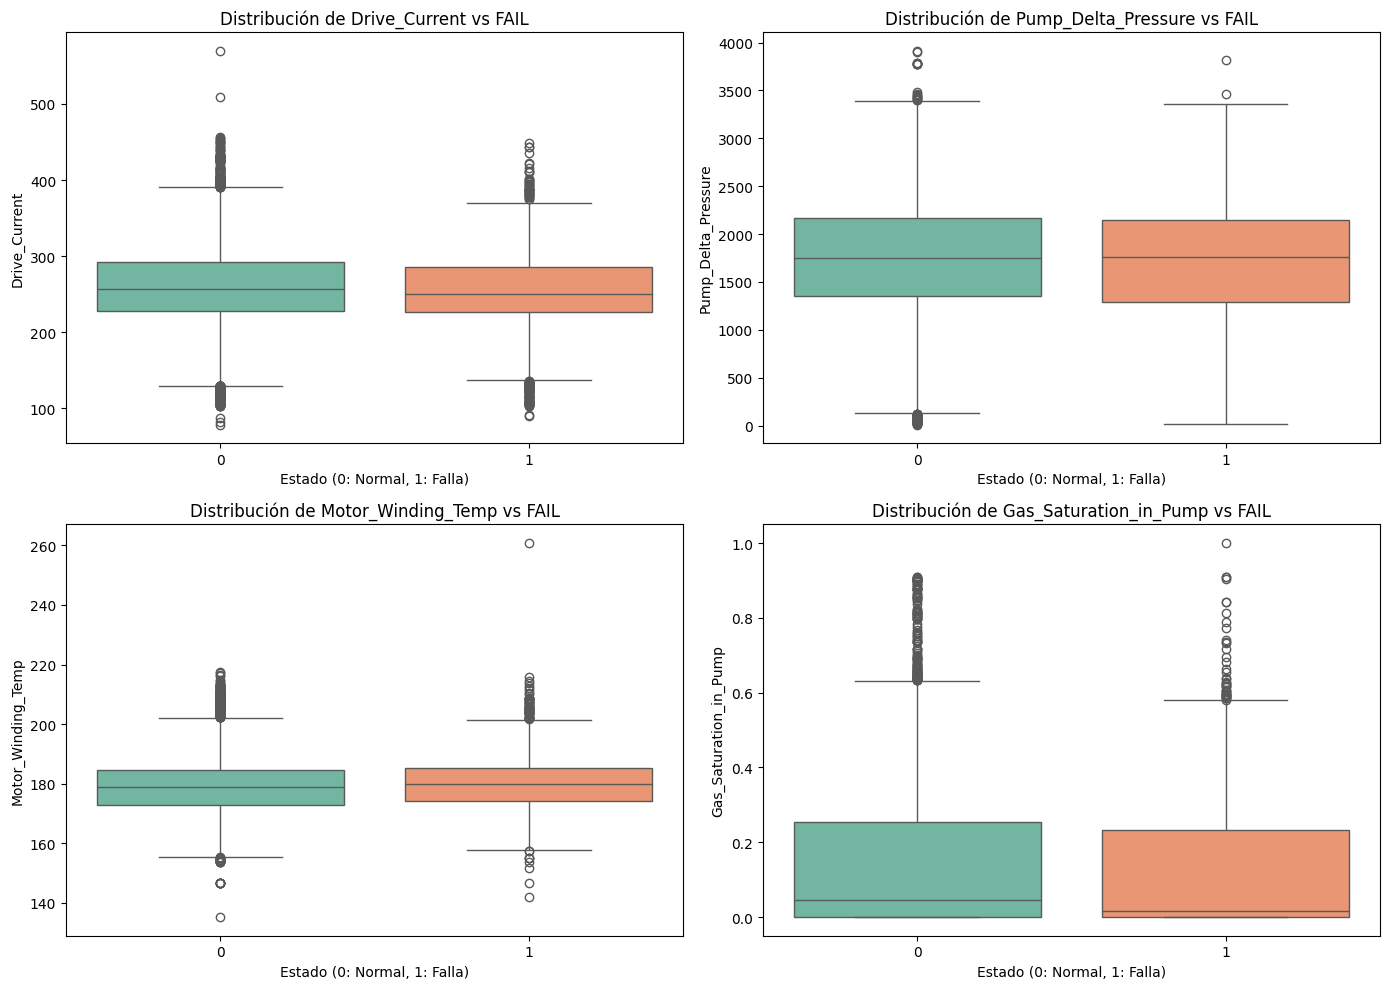

In [30]:
# Elegimos 4 variables estratégicas de nuestro análisis previo
variables_clave = [
    'Drive_Current',         # Eléctrico
    'Pump_Delta_Pressure',   # Hidráulico
    'Motor_Winding_Temp',    # Térmico/Salud
    'Gas_Saturation_in_Pump' # Fluidos/Gas
]

# Creamos la figura con 4 subplots (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Aplanamos el arreglo de ejes para iterar fácilmente
axes = axes.flatten()

# Iteramos sobre nuestras variables para crear un boxplot en cada espacio
for i, var in enumerate(variables_clave):
    sns.boxplot(x='FAIL', y=var, data=df_fails, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {var} vs FAIL')
    axes[i].set_xlabel('Estado (0: Normal, 1: Falla)')

plt.tight_layout()
plt.show()

#### **6. Vamos a separar las variables predictoras de nuestra variable objeto**

In [36]:
variable_objeto = df_fails['FAIL']
variable_predictores = df_fails.drop('FAIL', axis=1)


KeyError: "['FAIL'] not found in axis"

***
# END